# Exploración inicial y baseline

## Predicción del riesgo de incumplimiento en Lending Club

**Pregunta predictiva:** ¿Cuál es la probabilidad de que un préstamo personal termine en incumplimiento, utilizando únicamente información disponible al momento de evaluar la solicitud?

**Objetivo:** `Charged Off = 1` y `Fully Paid = 0`.

**Muestra:** 115,000 préstamos, 151 variables, años 2007 a 2018 y plazos de 36 y 60 meses.

## 1. Carga de la muestra

Se utiliza una muestra aleatoria reproducible de préstamos con resultado definitivo, generada con `scripts/crear_muestra.py` (semilla 42). La selección conserva las variables originales; su composición real está en `data/sample_summary.json`. La muestra no representa a solicitantes rechazados ni a préstamos sin resultado definitivo.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import glob
import hashlib
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix,
                             f1_score, precision_score, recall_score,
                             roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

EXPECTED_SHA256 = "c863e3348c96428195f158bf456c8abc289515737d77f59981804c1f5eed82da"
SAMPLE_URL = ("https://raw.githubusercontent.com/Juan-Ferreyra/"
              "Lending-club-riesgo-crediticio/avance-semana-1-muestra-reproducible/"
              "data/lending_club_muestra.csv.gz")
candidates = (glob.glob("data/lending_club_muestra*.csv.gz")
              + glob.glob("../data/lending_club_muestra*.csv.gz")
              + glob.glob("/content/lending_club_muestra*.csv.gz")
              + glob.glob("../lending_club_muestra*.csv.gz")
              + glob.glob("lending_club_muestra*.csv.gz"))
DATA_PATH = next((Path(p) for p in candidates
                  if hashlib.sha256(Path(p).read_bytes()).hexdigest() == EXPECTED_SHA256), None)
if DATA_PATH is None:
    DATA_PATH = (Path("/content/lending_club_muestra_del_proyecto.csv.gz")
                 if Path("/content").is_dir() else Path("lending_club_muestra_del_proyecto.csv.gz"))
    print("Descargando la muestra del proyecto...")
    urlretrieve(SAMPLE_URL, DATA_PATH)
    if hashlib.sha256(DATA_PATH.read_bytes()).hexdigest() != EXPECTED_SHA256:
        raise ValueError("La muestra descargada no coincide con la versión esperada.")
df = pd.read_csv(DATA_PATH, compression="gzip", low_memory=False)
print(f"Archivo: {DATA_PATH}")
print(f"Dimensiones: {df.shape}")

Archivo: ..\data\lending_club_muestra.csv.gz
Dimensiones: (115000, 151)


## 2. Número de filas, columnas y tipos de datos

In [2]:
print(f"Número de filas: {df.shape[0]:,}")
print(f"Número de columnas: {df.shape[1]:,}")

type_summary = (df.dtypes.astype(str).value_counts()
                .rename_axis("tipo").to_frame("cantidad_variables"))
display(type_summary)

variable_types = pd.DataFrame({
    "variable": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "valores_unicos": df.nunique(dropna=True).values,
})
display(variable_types)

Número de filas: 115,000
Número de columnas: 151


,cantidad_variables
tipo,
float64,114
str,36
int64,1


,variable,tipo,valores_unicos
0,id,int64,115000
1,member_id,float64,0
2,loan_amnt,float64,1400
3,funded_amnt,float64,1400
4,funded_amnt_inv,float64,2050
5,term,str,2
6,int_rate,float64,569
7,installment,float64,31315
8,grade,str,7
9,sub_grade,str,35


## 3. Porcentaje de valores faltantes por variable

In [3]:
missing_table = pd.DataFrame({
    "variable": df.columns,
    "faltantes": df.isna().sum().values,
    "porcentaje_faltantes": df.isna().mean().mul(100).values,
}).sort_values("porcentaje_faltantes", ascending=False)
display(missing_table)
print("Variables con 50% o más de faltantes:",
      int((missing_table["porcentaje_faltantes"] >= 50).sum()))
print("Variables con 95% o más de faltantes:",
      int((missing_table["porcentaje_faltantes"] >= 95).sum()))

,variable,faltantes,porcentaje_faltantes
1,member_id,115000,100.0000
49,next_pymnt_d,115000,100.0000
140,orig_projected_additional_accrued_interest,114682,99.7235
141,hardship_payoff_balance_amount,114498,99.5635
142,hardship_last_payment_amount,114498,99.5635
130,hardship_reason,114498,99.5635
129,hardship_type,114498,99.5635
131,hardship_status,114498,99.5635
133,hardship_amount,114498,99.5635
132,deferral_term,114498,99.5635


Variables con 50% o más de faltantes: 58
Variables con 95% o más de faltantes: 38


## 4. Distribución de la variable objetivo

La variable objetivo se construye con los resultados definitivos presentes en la muestra.

In [4]:
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()
df["target"] = (df["loan_status"] == "Charged Off").astype(int)
df["issue_date"] = pd.to_datetime(df["issue_d"], format="%b-%Y", errors="coerce")
df["issue_year"] = df["issue_date"].dt.year

target_distribution = (df["loan_status"].value_counts()
                       .rename_axis("estado").to_frame("cantidad"))
target_distribution["porcentaje"] = target_distribution["cantidad"] / len(df) * 100
display(target_distribution)
print(f"Periodo: {df['issue_date'].min():%Y-%m} a {df['issue_date'].max():%Y-%m}")
print(f"Duplicados completos: {df.duplicated().sum():,}")

,cantidad,porcentaje
estado,,
Fully Paid,91959,79.9643
Charged Off,23041,20.0357


Periodo: 2007-07 a 2018-12


Duplicados completos: 0


## 5. Visualizaciones exploratorias

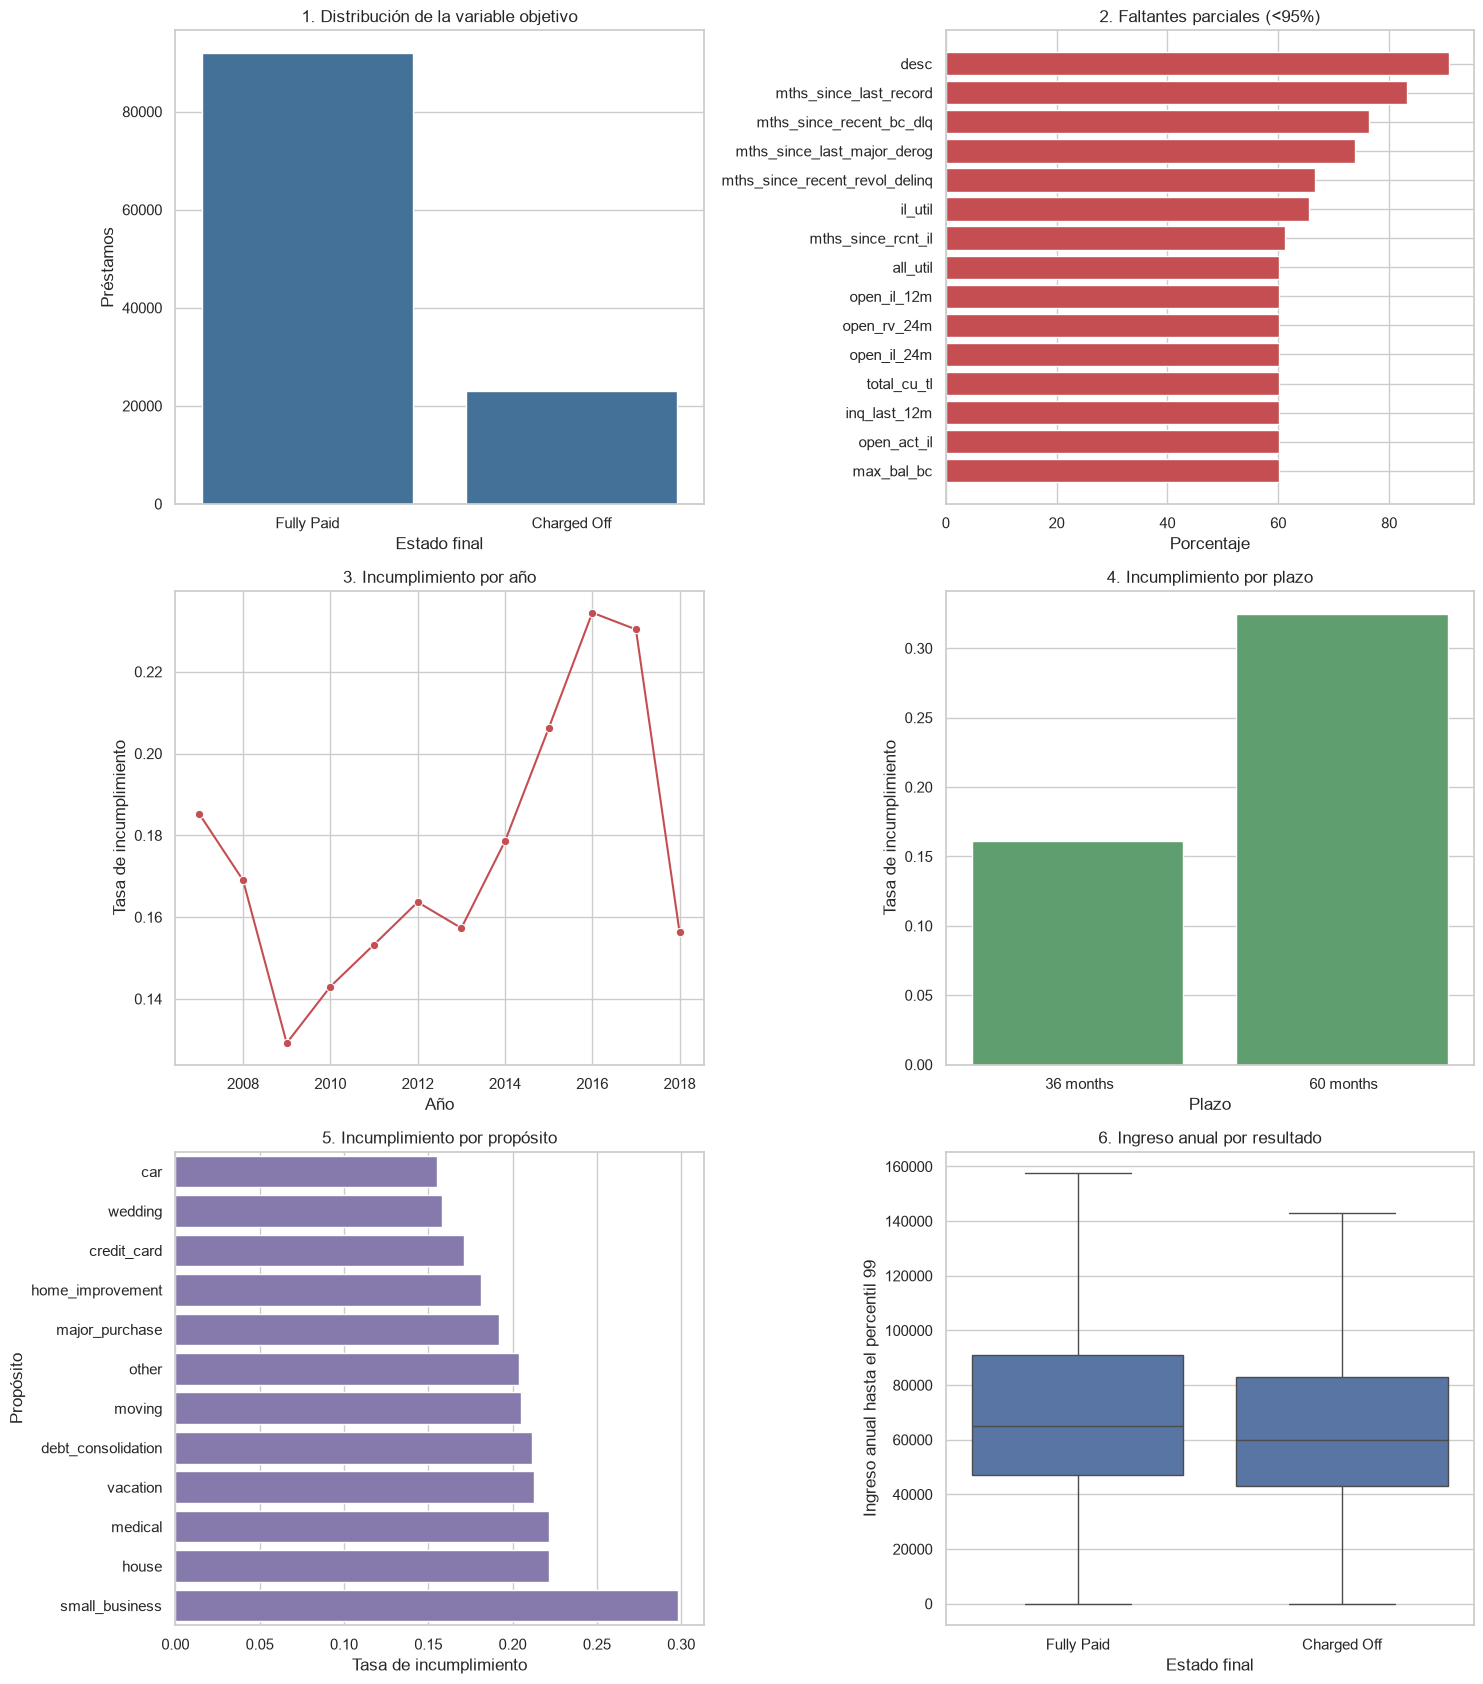

,issue_year,target
0,2007,0.1852
1,2008,0.1690
2,2009,0.1292
3,2010,0.1430
4,2011,0.1533
5,2012,0.1637
6,2013,0.1573
7,2014,0.1785
8,2015,0.2062
9,2016,0.2344


,term,target
0,36 months,0.1608
1,60 months,0.3249


,purpose,mean,size
0,car,0.1550,1252
1,wedding,0.1579,190
2,credit_card,0.1714,25150
3,home_improvement,0.1810,7481
4,major_purchase,0.1919,2533
5,other,0.2040,6569
6,moving,0.2051,824
7,debt_consolidation,0.2116,66821
8,vacation,0.2128,813
9,medical,0.2216,1381


In [5]:
fig, axes = plt.subplots(3, 2, figsize=(15, 17))

sns.countplot(data=df, x="loan_status",
              order=["Fully Paid", "Charged Off"],
              color="#3572A5", ax=axes[0, 0])
axes[0, 0].set_title("1. Distribución de la variable objetivo")
axes[0, 0].set_xlabel("Estado final")
axes[0, 0].set_ylabel("Préstamos")

top_missing = (missing_table[missing_table["porcentaje_faltantes"] < 95]
               .head(15).sort_values("porcentaje_faltantes"))
axes[0, 1].barh(top_missing["variable"],
                top_missing["porcentaje_faltantes"], color="#C44E52")
axes[0, 1].set_title("2. Faltantes parciales (<95%)")
axes[0, 1].set_xlabel("Porcentaje")

default_by_year = df.groupby("issue_year")["target"].mean().reset_index()
sns.lineplot(data=default_by_year, x="issue_year",
             y="target", marker="o", color="#C44E52", ax=axes[1, 0])
axes[1, 0].set_title("3. Incumplimiento por año")
axes[1, 0].set_xlabel("Año")
axes[1, 0].set_ylabel("Tasa de incumplimiento")

term_rates = df.groupby("term")["target"].mean().reset_index()
sns.barplot(data=term_rates, x="term", y="target",
            color="#55A868", ax=axes[1, 1])
axes[1, 1].set_title("4. Incumplimiento por plazo")
axes[1, 1].set_xlabel("Plazo")
axes[1, 1].set_ylabel("Tasa de incumplimiento")

purpose_rates = (df.groupby("purpose")["target"].agg(["mean", "size"])
                 .query("size >= 100").sort_values("mean").reset_index())
sns.barplot(data=purpose_rates, y="purpose", x="mean",
            color="#8172B3", ax=axes[2, 0])
axes[2, 0].set_title("5. Incumplimiento por propósito")
axes[2, 0].set_xlabel("Tasa de incumplimiento")
axes[2, 0].set_ylabel("Propósito")

income_limit = df["annual_inc"].quantile(0.99)
income_plot = df[df["annual_inc"].le(income_limit)]
sns.boxplot(data=income_plot, x="loan_status", y="annual_inc",
            order=["Fully Paid", "Charged Off"], showfliers=False,
            color="#4C72B0", ax=axes[2, 1])
axes[2, 1].set_title("6. Ingreso anual por resultado")
axes[2, 1].set_xlabel("Estado final")
axes[2, 1].set_ylabel("Ingreso anual hasta el percentil 99")

plt.tight_layout()
plt.show()
display(default_by_year)
display(term_rates)
display(purpose_rates)

**Lectura inicial:** La tasa por año describe solo préstamos con resultado definitivo. La caída de 2018 puede reflejar que muchos préstamos recientes aún no habían terminado, y no demuestra una mejora real del riesgo. Las tasas por propósito también deben leerse junto con el tamaño de cada grupo.

## 6. Identificación de outliers o registros sospechosos

La regla del rango intercuartílico se usa como diagnóstico. Los registros no se eliminan automáticamente porque un valor extremo puede ser válido.

In [6]:
outlier_variables = ["loan_amnt", "annual_inc", "dti", "delinq_2yrs",
                     "revol_bal", "revol_util", "open_acc", "total_acc"]
rows = []
for column in outlier_variables:
    values = pd.to_numeric(df[column], errors="coerce")
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = (values < lower) | (values > upper)
    rows.append({"variable": column, "mínimo": values.min(),
                 "mediana": values.median(), "p99": values.quantile(0.99),
                 "máximo": values.max(),
                 "cantidad_fuera_iqr": int(outliers.sum()),
                 "porcentaje_fuera_iqr": outliers.mean() * 100})
outlier_table = pd.DataFrame(rows).sort_values("porcentaje_fuera_iqr", ascending=False)
display(outlier_table)
print("Ingresos iguales a cero:", int(df["annual_inc"].eq(0).sum()))
print("DTI negativo:", int(df["dti"].lt(0).sum()))
print("Revol util superior a 100:", int(df["revol_util"].gt(100).sum()))

,variable,mínimo,mediana,p99,máximo,cantidad_fuera_iqr,porcentaje_fuera_iqr
3,delinq_2yrs,0.0000,0.0000,4.0000,30.0000,22221,19.3226
4,revol_bal,0.0000,"11,146.0000","95,074.0800","1,023,940.0000",6857,5.9626
1,annual_inc,0.0000,"65,000.0000","254,000.0000","9,550,000.0000",5629,4.8948
6,open_acc,0.0000,11.0000,29.0000,90.0000,3813,3.3157
7,total_acc,2.0000,23.0000,61.0000,156.0000,1873,1.6287
0,loan_amnt,700.0000,"12,000.0000","35,000.0000","40,000.0000",577,0.5017
2,dti,0.0000,17.6100,38.5034,999.0000,464,0.4035
5,revol_util,0.0000,52.2000,98.2000,165.8000,10,0.0087


Ingresos iguales a cero: 32
DTI negativo: 0
Revol util superior a 100: 410


## 7. Discusión inicial de sesgos, leakage y limitaciones

### Leakage

Se excluyen variables generadas después del otorgamiento, como pagos, capital pendiente, recuperaciones, fechas de pago, cobranzas, hardship y settlement. También se excluyen `grade`, `sub_grade`, `int_rate` e `installment` porque reflejan la evaluación y el precio definidos por Lending Club.

### Sesgos y limitaciones

- El dataset contiene préstamos aceptados y no representa a todos los solicitantes.
- La ubicación, vivienda e ingresos pueden actuar como proxies socioeconómicos.
- Las políticas y condiciones económicas cambiaron entre 2007 y 2018.
- `Charged Off` es la clase minoritaria.
- Algunos faltantes son estructurales porque ciertas variables aparecieron después.
- Los resultados definitivos recientes pueden no representar a todos los préstamos emitidos en esos años.
- Los datos corresponden a Lending Club en Estados Unidos.
- El modelo identifica asociaciones históricas, no relaciones causales.

In [7]:
leakage_columns = [
    "loan_status", "out_prncp", "out_prncp_inv", "total_pymnt",
    "total_pymnt_inv", "total_rec_prncp", "total_rec_int",
    "total_rec_late_fee", "recoveries", "collection_recovery_fee",
    "last_pymnt_d", "last_pymnt_amnt", "next_pymnt_d",
    "last_credit_pull_d", "last_fico_range_high", "last_fico_range_low",
    "grade", "sub_grade", "int_rate", "installment"
]
leakage_review = pd.DataFrame({
    "variable": [c for c in leakage_columns if c in df.columns],
    "decisión": "Excluir del baseline",
})
display(leakage_review)

,variable,decisión
0,loan_status,Excluir del baseline
1,out_prncp,Excluir del baseline
2,out_prncp_inv,Excluir del baseline
3,total_pymnt,Excluir del baseline
4,total_pymnt_inv,Excluir del baseline
5,total_rec_prncp,Excluir del baseline
6,total_rec_int,Excluir del baseline
7,total_rec_late_fee,Excluir del baseline
8,recoveries,Excluir del baseline
9,collection_recovery_fee,Excluir del baseline


## 8. Primer baseline simple

Se utiliza regresión logística. La división es estratificada: 70% entrenamiento, 15% validación y 15% prueba.

In [8]:
numeric_features = ["loan_amnt", "annual_inc", "dti", "delinq_2yrs",
                    "fico_range_low", "fico_range_high", "inq_last_6mths",
                    "open_acc", "pub_rec", "revol_bal", "revol_util", "total_acc"]
categorical_features = ["term", "emp_length", "home_ownership",
                        "verification_status", "purpose", "addr_state",
                        "application_type"]
features = numeric_features + categorical_features
X, y = df[features], df["target"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

display(pd.DataFrame({
    "partición": ["Entrenamiento", "Validación"],
    "filas": [len(X_train), len(X_validation)],
    "tasa_incumplimiento": [y_train.mean(), y_validation.mean()],
}))
print(f"Prueba reservada: {len(X_test):,} filas; etiquetas sin examinar.")

,partición,filas,tasa_incumplimiento
0,Entrenamiento,80500,0.2004
1,Validación,17250,0.2003


Prueba reservada: 17,250 filas; etiquetas sin examinar.


In [9]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])
baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced",
                                 solver="lbfgs", random_state=RANDOM_STATE)),
])
baseline.fit(X_train, y_train)
print("Baseline entrenado correctamente.")

Baseline entrenado correctamente.


In [10]:
def evaluate(model, X_data, y_data, threshold=0.5):
    probabilities = model.predict_proba(X_data)[:, 1]
    predictions = (probabilities >= threshold).astype(int)
    return {
        "filas": len(y_data),
        "tasa_incumplimiento": y_data.mean(),
        "PR-AUC": average_precision_score(y_data, probabilities),
        "ROC-AUC": roc_auc_score(y_data, probabilities),
        "precision": precision_score(y_data, predictions, zero_division=0),
        "recall": recall_score(y_data, predictions),
        "F1": f1_score(y_data, predictions),
        "matriz_confusión": confusion_matrix(y_data, predictions).tolist(),
    }

validation_metrics = evaluate(baseline, X_validation, y_validation)
display(pd.DataFrame([validation_metrics], index=["Validación"]).drop(columns="matriz_confusión"))
print("Matriz de validación:", validation_metrics["matriz_confusión"])
print("Referencia mínima para PR-AUC:", f"{y_validation.mean():.4f}")
print("La partición de prueba queda reservada para la evaluación final.")

,filas,tasa_incumplimiento,PR-AUC,ROC-AUC,precision,recall,F1
Validación,17250,0.2003,0.3610,0.6948,0.3120,0.6418,0.4199


Matriz de validación: [[8903, 4891], [1238, 2218]]
Referencia mínima para PR-AUC: 0.2003
La partición de prueba queda reservada para la evaluación final.


### Lectura inicial del baseline

En validación, la PR-AUC de 0.3610 supera la prevalencia de incumplimiento de 0.2003, referencia para un modelo sin capacidad de ordenamiento. La ROC-AUC es 0.6948. Con umbral 0.5, el recall de 0.6418 permite detectar parte de los incumplimientos, pero la precisión de 0.3120 refleja una cantidad importante de falsos positivos. Estos resultados son preliminares: la división es aleatoria y aún no se ha evaluado la estabilidad temporal. La partición de prueba permanece reservada.

In [11]:
prevalencia = y_validation.mean()
pr_auc = validation_metrics['PR-AUC']
print(f'PR-AUC en validación: {pr_auc:.4f}; referencia por prevalencia: {prevalencia:.4f}; razón: {pr_auc / prevalencia:.2f} veces.')
print(f'ROC-AUC: {validation_metrics["ROC-AUC"]:.4f}; precisión: {validation_metrics["precision"]:.4f}; recall: {validation_metrics["recall"]:.4f}.')
print('Esta primera comparación es interna a la muestra; falta estudiar estabilidad temporal y otros sesgos.')

PR-AUC en validación: 0.3610; referencia por prevalencia: 0.2003; razón: 1.80 veces.
ROC-AUC: 0.6948; precisión: 0.3120; recall: 0.6418.
Esta primera comparación es interna a la muestra; falta estudiar estabilidad temporal y otros sesgos.
